# Data Cleaning y Feature Engineering

Aquí procederemos con la limpieza de los datos y feature engineering previo al modelado.

In [1]:
# ==============================================================================
# PROYECTO: El Oráculo del Balón - Predicción Mundial 2026
# CUADERNO 01: Limpieza de Datos, Feature Engineering (ELO) y EDA
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configuración visual para los gráficos del paper IEEE
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)
warnings.filterwarnings('ignore')

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [2]:
# Cargar el dataset
ruta_datos = '../data/raw/results.csv' 
try:
    df = pd.read_csv(ruta_datos)
    print(f"Dataset cargado exitosamente con {df.shape[0]} registros y {df.shape[1]} columnas.")
except FileNotFoundError:
    print(f"Error: No se encontró el archivo en {ruta_datos}. Verifica la ruta.")

# Verificamos los datos en las columnas
df.info()


Dataset cargado exitosamente con 49329 registros y 9 columnas.
<class 'pandas.DataFrame'>
RangeIndex: 49329 entries, 0 to 49328
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49329 non-null  str    
 1   home_team   49329 non-null  str    
 2   away_team   49329 non-null  str    
 3   home_score  49257 non-null  float64
 4   away_score  49257 non-null  float64
 5   tournament  49329 non-null  str    
 6   city        49329 non-null  str    
 7   country     49329 non-null  str    
 8   neutral     49329 non-null  bool   
dtypes: bool(1), float64(2), str(6)
memory usage: 3.1 MB


In [3]:

# - Eliminar partidos sin resultado registrado (nulos)
df = df.dropna(subset=['home_score', 'away_score']).copy()

# - Convertir fecha a datetime para operaciones temporales
df['date'] = pd.to_datetime(df['date'])

# - Ordenar cronológicamente (VITAL para el cálculo de ELO)
df = df.sort_values('date').reset_index(drop=True)

print(f"Dataset limpio. Total de partidos válidos: {len(df)}.")


Dataset limpio. Total de partidos válidos: 49257.


## Feature Engineering

Procedemos a crear las diferentes características

In [4]:
# FEATURE 1: Variable Objetivo (Target) -> 2: Gana Local, 1: Empate, 0: Gana Visitante
condiciones = [
    df['home_score'] > df['away_score'],
    df['home_score'] == df['away_score'],
    df['home_score'] < df['away_score']
]
df['target'] = np.select(condiciones, [2, 1, 0])

# FEATURE 2: Ventaja de Localía (Home Advantage)
# 1 si juega en casa, 0 si es cancha neutral
df['home_advantage'] = np.where(df['neutral'] == False, 1, 0)

# FEATURE 3: Contexto del Partido (Oficial vs Amistoso)
df['is_friendly'] = np.where(df['tournament'] == 'Friendly', 1, 0)

print("Características 1, 2 y 3 generadas exitosamente.")

Características 1, 2 y 3 generadas exitosamente.


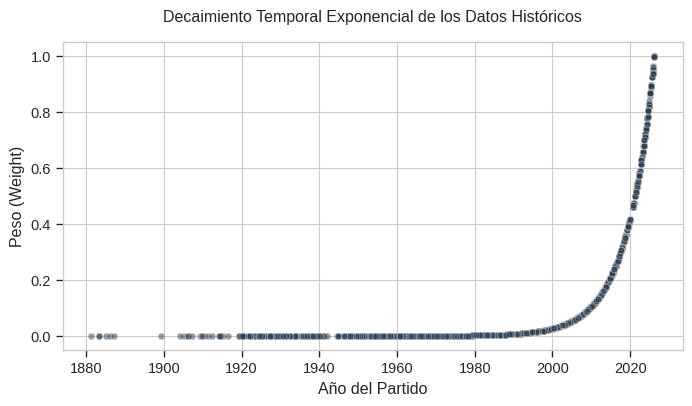

Gráfico de decaimiento guardado en /docs/figuras/


In [5]:
# FEATURE 4: Decaimiento Temporal Exponencial (Time Decay Weight)
# Damos más peso a los partidos recientes. Vida media (half-life) = 5 años.

fecha_actual = df['date'].max()
df['days_ago'] = (fecha_actual - df['date']).dt.days

half_life_days = 1825 # 5 años
lambda_decay = np.log(2) / half_life_days
df['time_decay_weight'] = np.exp(-lambda_decay * df['days_ago'])


plt.figure(figsize=(8, 4))
muestra_temporal = df.sample(2000) # Muestra para no saturar el gráfico
sns.scatterplot(x=muestra_temporal['date'], y=muestra_temporal['time_decay_weight'], alpha=0.5, color='#2c3e50')
plt.title('Decaimiento Temporal Exponencial de los Datos Históricos', pad=15)
plt.xlabel('Año del Partido')
plt.ylabel('Peso (Weight)')
plt.savefig('../docs/figuras/time_decay_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico de decaimiento guardado en /docs/figuras/")

In [6]:
# FEATURES 5 y 6: ELO Dinámico y Diferencia de ELO
elo_dict = {}
DEFAULT_ELO = 1500
K = 20

home_elo_list = []
away_elo_list = []

print("Calculando Ranking ELO histórico partido a partido. Por favor espera...")

for index, row in df.iterrows():
    home, away = row['home_team'], row['away_team']
    
    # Asignar ELO base si son debutantes en el registro
    if home not in elo_dict: elo_dict[home] = DEFAULT_ELO
    if away not in elo_dict: elo_dict[away] = DEFAULT_ELO
    
    elo_h, elo_a = elo_dict[home], elo_dict[away]
    home_elo_list.append(elo_h)
    away_elo_list.append(elo_a)
    
    # Cálculos matemáticos de expectativa
    expected_h = 1 / (1 + 10 ** ((elo_a - elo_h) / 400))
    expected_a = 1 / (1 + 10 ** ((elo_h - elo_a) / 400))
    
    # Asignación de resultados (1, 0.5, 0)
    if row['target'] == 2: w_h, w_a = 1, 0
    elif row['target'] == 0: w_h, w_a = 0, 1
    else: w_h, w_a = 0.5, 0.5
        
    # Actualización POST-partido
    elo_dict[home] = elo_h + K * (w_h - expected_h)
    elo_dict[away] = elo_a + K * (w_a - expected_a)

df['home_elo'] = home_elo_list
df['away_elo'] = away_elo_list
df['elo_difference'] = df['home_elo'] - df['away_elo']

print("¡Motor ELO ejecutado exitosamente!")

Calculando Ranking ELO histórico partido a partido. Por favor espera...
¡Motor ELO ejecutado exitosamente!


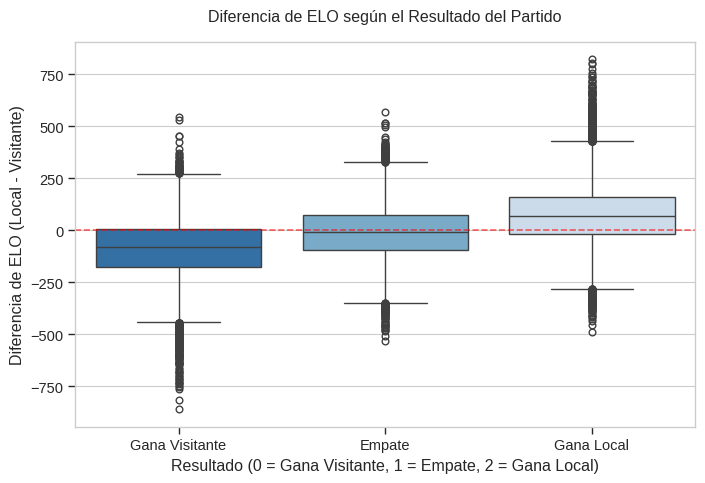

Boxplot de ELO guardado en /docs/figuras/


In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='target', y='elo_difference', data=df, palette='Blues_r')
plt.title('Diferencia de ELO según el Resultado del Partido', pad=15)
plt.xlabel('Resultado (0 = Gana Visitante, 1 = Empate, 2 = Gana Local)')
plt.ylabel('Diferencia de ELO (Local - Visitante)')
plt.xticks(ticks=[0, 1, 2], labels=['Gana Visitante', 'Empate', 'Gana Local'])

# Añadir línea de equilibrio (0 diferencia)
plt.axhline(0, color='red', linestyle='--', alpha=0.6)

plt.savefig('../docs/figuras/elo_diferencia_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()
print("Boxplot de ELO guardado en /docs/figuras/")

Guardamos los datos preprocesados

In [8]:
# Seleccionamos las variables finales
columnas_finales = [
    'date', 'home_team', 'away_team', 'tournament', # Metadatos útiles para los splits
    'home_elo', 'away_elo', 'elo_difference',       # Features ELO
    'home_advantage', 'is_friendly',                # Contexto
    'time_decay_weight',                            # Ponderación
    'target'                                        # Variable a predecir
]

df_final = df[columnas_finales].copy()

# Exportar a la carpeta de datos procesados
ruta_salida = '../data/processed/historical_matches_elo.csv'

import os
# Crear directorio si no existe
os.makedirs(os.path.dirname(ruta_salida), exist_ok=True) 

df_final.to_csv(ruta_salida, index=False)
print(f"Dataset preprocesado listo y exportado a: {ruta_salida}")
print("El Cuaderno 01 ha finalizado exitosamente.")

Dataset preprocesado listo y exportado a: ../data/processed/historical_matches_elo.csv
El Cuaderno 01 ha finalizado exitosamente.


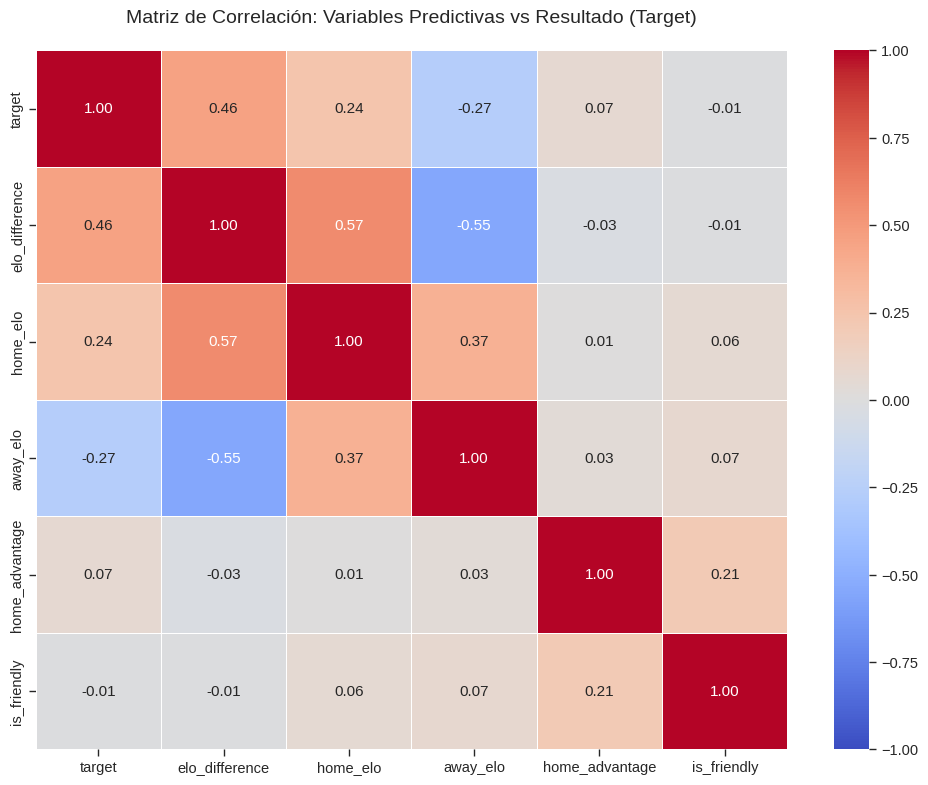


¡Matriz de correlación generada y guardada exitosamente en /docs/figuras/!


In [9]:
# Matriz de Correlación de Características

# Seleccionamos solo las variables numéricas clave para evaluar su relación
columnas_correlacion = [
    'target', 
    'elo_difference', 
    'home_elo', 
    'away_elo', 
    'home_advantage', 
    'is_friendly'
]

# Calculamos la matriz de correlación (Coeficiente de Pearson)
matriz_corr = df[columnas_correlacion].corr()

# Configuramos el gráfico con Seaborn
plt.figure(figsize=(10, 8))

# Utilizamos un mapa de colores divergente ('coolwarm') para resaltar 
# correlaciones positivas (rojo) y negativas (azul)
sns.heatmap(matriz_corr, 
            annot=True,          # Muestra los números exactos
            cmap='coolwarm', 
            vmin=-1, vmax=1,     # Escala estricta de -1 a 1
            linewidths=0.5, 
            fmt='.2f',           # 2 decimales
            annot_kws={"size": 11})

# 4. Títulos y ajustes finales
plt.title('Matriz de Correlación: Variables Predictivas vs Resultado (Target)', pad=20, fontsize=14)
plt.tight_layout()

# 5. Guardar la imagen en tu carpeta de figuras
plt.savefig('../docs/figuras/matriz_correlacion.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n¡Matriz de correlación generada y guardada exitosamente en /docs/figuras/!")

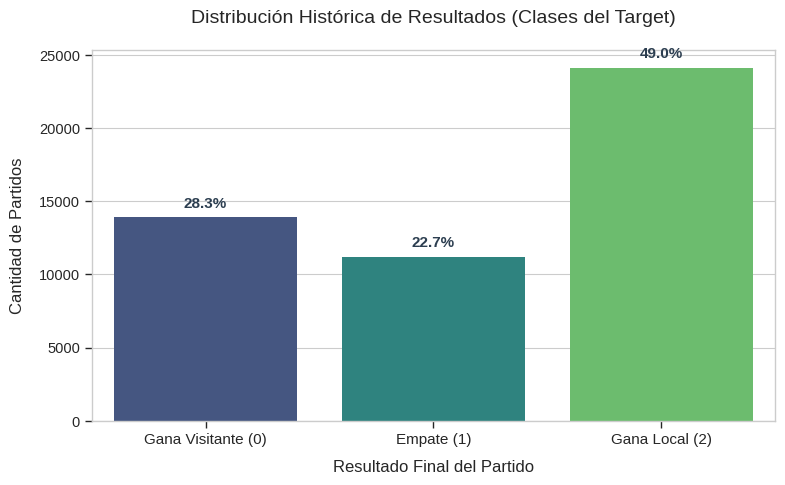


¡Gráfico de distribución generado y guardado exitosamente en /docs/figuras/!


In [10]:
# ==============================================================================
# Celda 6.6: EDA - Distribución de la Variable Objetivo (Target)
# ==============================================================================

plt.figure(figsize=(8, 5))

# 1. Crear el gráfico de conteo usando una paleta de colores profesional
ax = sns.countplot(data=df, x='target', palette='viridis')

# 2. Calcular e inyectar porcentajes encima de cada barra
total = len(df)
for p in ax.patches:
    porcentaje = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    # Anotar el porcentaje
    ax.annotate(porcentaje, (x, y), ha='center', va='bottom', 
                fontsize=11, fontweight='bold', color='#2c3e50', 
                xytext=(0, 5), textcoords='offset points')

# 3. Títulos y ajustes de etiquetas
plt.title('Distribución Histórica de Resultados (Clases del Target)', pad=20, fontsize=14)
plt.xlabel('Resultado Final del Partido', fontsize=12, labelpad=10)
plt.ylabel('Cantidad de Partidos', fontsize=12, labelpad=10)
plt.xticks(ticks=[0, 1, 2], labels=['Gana Visitante (0)', 'Empate (1)', 'Gana Local (2)'], fontsize=11)

# 4. Ajustar el diseño y guardar
plt.tight_layout()
plt.savefig('../docs/figuras/distribucion_target.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n¡Gráfico de distribución generado y guardado exitosamente en /docs/figuras/!")